# Object Detection with MATA

This notebook demonstrates how MATA result objects display automatically
in Jupyter notebooks using the rich HTML display protocol.

**Model used**: `facebook/detr-resnet-50` (requires HuggingFace Transformers)

**Prerequisites**: `pip install datamata[notebook]`

In [ ]:
# Uncomment to install if needed:
# !pip install datamata[notebook]
# !pip install timm (facebook/detr-resnet-50 need this)
# Follow README.md for installation instructions.

In [1]:
import mata
print(f"MATA version: {mata.__version__}")

MATA version: 1.9.3


In [2]:
# Load a detector once for repeated use
detector = mata.load("detect", "facebook/detr-resnet-50")

[INFO] Loading detect model from huggingface: facebook/detr-resnet-50


[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceDetectAdapter with device=cuda, threshold=0.3


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loading HuggingFace model: facebook/detr-resnet-50
[INFO] Detected architecture: detr
[INFO] Model loaded successfully on cuda


In [3]:
# Run inference on an image
result = detector.predict("../../examples/images/000000039769.jpg")

# Auto-display: just evaluate the result object in a cell
result

VisionResult(instances=[Instance(score=0.998219907283783, label=75, bbox=(40.16227340698242, 70.80741882324219, 175.54830932617188, 117.98204040527344), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.996005117893219, label=75, bbox=(333.2471008300781, 72.55055236816406, 368.32958984375, 187.6637725830078), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9954837560653687, label=63, bbox=(-0.022182464599609375, 1.1494159698486328, 639.7268676757812, 473.76220703125), mask=None, label_name='couch', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.99880051612854, label=17, bbox=(13.244609832763672, 52.04668426513672, 314.015869140625, 470.93463134765625), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9986791014671326, label=17,

[INFO] Exported detection overlay to ..\..\examples\images\000000039769_result.jpg


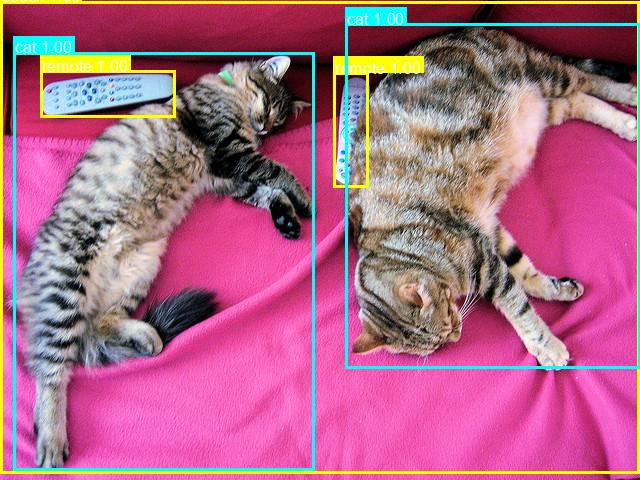

In [8]:
from IPython.display import Image
# Save the result image to disk and display it
result.save("../../examples/images/000000039769_result.jpg")
Image(filename='../../examples/images/000000039769_result.jpg') 

In [9]:
# Filter by confidence and display again
high_conf = result.filter_by_score(0.7)
print(f"Instances above 0.7 confidence: {len(high_conf.instances)}")
high_conf

Instances above 0.7 confidence: 5


VisionResult(instances=[Instance(score=0.998219907283783, label=75, bbox=(40.16227340698242, 70.80741882324219, 175.54830932617188, 117.98204040527344), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.996005117893219, label=75, bbox=(333.2471008300781, 72.55055236816406, 368.32958984375, 187.6637725830078), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9954837560653687, label=63, bbox=(-0.022182464599609375, 1.1494159698486328, 639.7268676757812, 473.76220703125), mask=None, label_name='couch', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.99880051612854, label=17, bbox=(13.244609832763672, 52.04668426513672, 314.015869140625, 470.93463134765625), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9986791014671326, label=17,

## Change the model and run inference again

In [14]:
# Load a different detector (torchvision's fasterrcnn_resnet50_fpn_v2) and run inference again
detector = mata.load("detect", "torchvision/fasterrcnn_resnet50_fpn_v2")

[INFO] Loading detect model from torchvision: torchvision/fasterrcnn_resnet50_fpn_v2
[INFO] Loading torchvision detection model: torchvision/fasterrcnn_resnet50_fpn_v2
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized TorchvisionDetectAdapter with device=cuda, threshold=0.3
[INFO] Loading torchvision model: fasterrcnn_resnet50_fpn_v2
[INFO] Loaded with new API (weights='DEFAULT')
[INFO] Model loaded successfully on cuda


In [19]:
# Run inference on an image
result = detector.predict("../../examples/images/000000039769.jpg")

# Auto-display: just evaluate the result object in a cell
result

VisionResult(instances=[Instance(score=0.9987527132034302, label=17, bbox=(338.86102294921875, 18.4385929107666, 640.0, 364.3980712890625), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9985785484313965, label=17, bbox=(15.835758209228516, 49.97514343261719, 324.2213134765625, 465.991943359375), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9755483865737915, label=75, bbox=(36.67140197753906, 73.94468688964844, 176.12892150878906, 119.98531341552734), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.8689357042312622, label=63, bbox=(5.549293518066406, 0.0, 640.0, 467.7547302246094), mask=None, label_name='couch', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.7271059155464172, label=75, bbox=(333.02825927734375, 76.776245117

[INFO] Exported detection overlay to ..\..\examples\images\000000039769_result_1.jpg


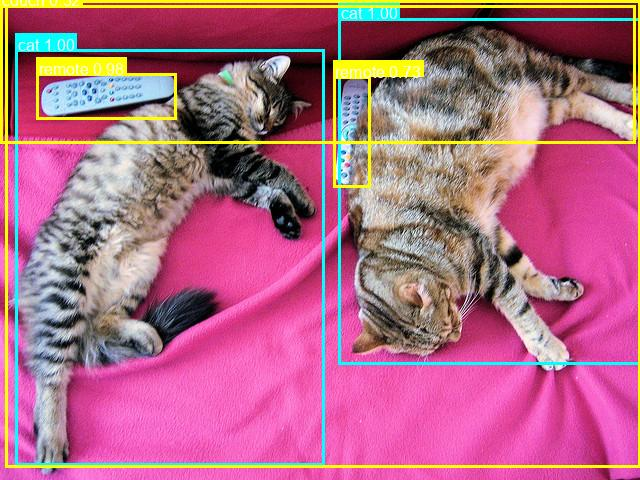

In [20]:
from IPython.display import Image
# Save the result image to disk and display it
result.save("../../examples/images/000000039769_result_1.jpg")
Image(filename='../../examples/images/000000039769_result_1.jpg') 

In [17]:
# Filter by confidence and display again
high_conf = result.filter_by_score(0.7)
print(f"Instances above 0.7 confidence: {len(high_conf.instances)}")
high_conf

Instances above 0.7 confidence: 5


VisionResult(instances=[Instance(score=0.9987527132034302, label=17, bbox=(338.86102294921875, 18.4385929107666, 640.0, 364.3980712890625), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9985785484313965, label=17, bbox=(15.835758209228516, 49.97514343261719, 324.2213134765625, 465.991943359375), mask=None, label_name='cat', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.9755483865737915, label=75, bbox=(36.67140197753906, 73.94468688964844, 176.12892150878906, 119.98531341552734), mask=None, label_name='remote', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.8689357042312622, label=63, bbox=(5.549293518066406, 0.0, 640.0, 467.7547302246094), mask=None, label_name='couch', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None), Instance(score=0.7271059155464172, label=75, bbox=(333.02825927734375, 76.776245117

## Notes

- `result` auto-renders as a rich HTML table in Jupyter cells
- `mata.show(result, image=...)` adds a visual image overlay
- `result.filter_by_score(threshold)` returns a new result with only high-confidence detections
- `result.to_json()` exports the full result as JSON